# Case 4: Heat Diffusion Equation with Source Term

## Governing Equation

$$
\frac{\partial y}{\partial t}
=
\frac{\partial^2 y}{\partial x^2}
+1
$$

## Boundary Conditions

Left Boundary:

$$
y(0)=1
$$

Right Boundary:

$$
\frac{dy}{dx}(1)=0
$$

## Initial Condition

$$
y(x,0)=\sin(\pi x)
$$

## Objective

To study the transient and steady-state behaviour of the one-dimensional heat diffusion equation with a uniform source term using the finite volume method implemented in FiPy.

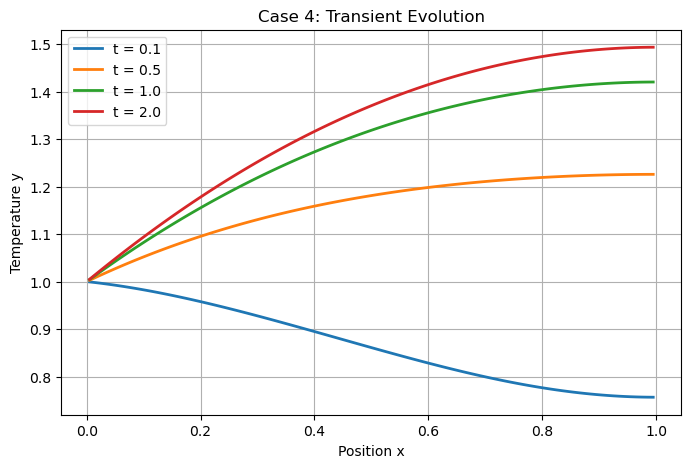

In [1]:
# =====================================================
# TRANSIENT ANALYSIS
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# Domain
L = 1.0
nx = 100
dx = L / nx

# Mesh
mesh = Grid1D(nx=nx, dx=dx)
x = np.array(mesh.cellCenters[0])

# Initial Condition
phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

# Boundary Conditions
phi.constrain(1.0, mesh.facesLeft)
phi.faceGrad.constrain([0.0], mesh.facesRight)

# Governing Equation
eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=1.0)
    + 1.0
)

# Time Step
dt = 1e-3

# Larger times to better observe evolution
times = [0.1, 0.5, 1.0, 2.0]
steps_required = [int(t / dt) for t in times]

solutions = []
current_step = 0

for target_step in steps_required:

    while current_step < target_step:
        eq.solve(var=phi, dt=dt)
        current_step += 1

    solutions.append(phi.value.copy())

# Plot
plt.figure(figsize=(8,5))

for sol, t in zip(solutions, times):
    plt.plot(
        x,
        sol,
        linewidth=2,
        label=f't = {t:.1f}'
    )

plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.title("Case 4: Transient Evolution")
plt.legend()
plt.grid(True)

plt.show()

## Observation

The transient temperature profiles evolve from the initial sinusoidal distribution toward the steady-state solution.

The presence of the uniform source term continuously adds heat to the domain, causing the temperature to increase with time. The left boundary remains fixed at y(0)=1, while the zero-gradient condition at x=1 produces a smooth flattening of the profile near the right boundary.

As time progresses, the solution approaches the analytical steady-state profile:

$$
y=1+x-\frac{x^2}{2}
$$

which is a downward-opening parabolic distribution.

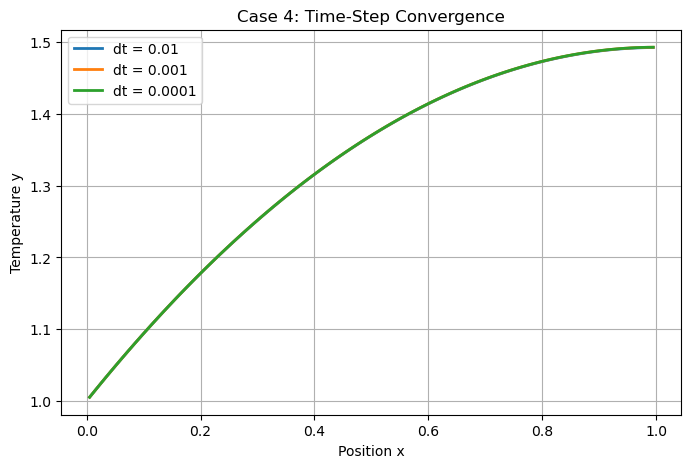

In [3]:
# =====================================================
# TIME-STEP CONVERGENCE
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# Domain
L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)
x = np.array(mesh.cellCenters[0])

dt_values = [1e-2, 1e-3, 1e-4]

solutions = []

for dt in dt_values:

    phi = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=np.sin(np.pi * x)
    )

    # Boundary Conditions
    phi.constrain(1.0, mesh.facesLeft)
    phi.faceGrad.constrain([0.0], mesh.facesRight)

    # Governing Equation
    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=1.0)
        + 1.0
    )

    final_time = 2.0
    steps = int(final_time / dt)

    for step in range(steps):
        eq.solve(var=phi, dt=dt)

    solutions.append(phi.value.copy())

# Plot
plt.figure(figsize=(8,5))

for sol, dt in zip(solutions, dt_values):
    plt.plot(
        x,
        sol,
        linewidth=2,
        label=f'dt = {dt}'
    )

plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.title("Case 4: Time-Step Convergence")
plt.legend()
plt.grid(True)

plt.show()

## Observation

The temperature profiles obtained using time steps of 10⁻², 10⁻³ and 10⁻⁴ overlap almost completely throughout the domain.

The negligible difference between the curves indicates that the numerical solution has converged with respect to the time-step size.

The results demonstrate the temporal stability and accuracy of the finite volume formulation.

Since further reduction of the time step does not produce noticeable changes in the solution, a time step of 10⁻³ is considered sufficient for the remaining simulations.

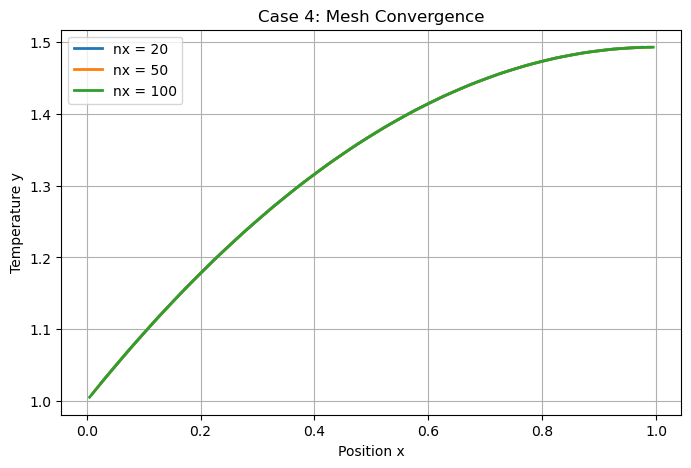

In [4]:
# =====================================================
# MESH CONVERGENCE
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# Domain
L = 1.0

nx_values = [20, 50, 100]

solutions = []
x_coordinates = []

for nx in nx_values:

    dx = L / nx

    mesh = Grid1D(nx=nx, dx=dx)
    x = np.array(mesh.cellCenters[0])

    phi = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=np.sin(np.pi * x)
    )

    # Boundary Conditions
    phi.constrain(1.0, mesh.facesLeft)
    phi.faceGrad.constrain([0.0], mesh.facesRight)

    # Governing Equation
    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=1.0)
        + 1.0
    )

    dt = 1e-3
    final_time = 2.0
    steps = int(final_time / dt)

    for step in range(steps):
        eq.solve(var=phi, dt=dt)

    solutions.append(phi.value.copy())
    x_coordinates.append(x)

# Plot
plt.figure(figsize=(8,5))

for x, sol, nx in zip(x_coordinates, solutions, nx_values):
    plt.plot(
        x,
        sol,
        linewidth=2,
        label=f'nx = {nx}'
    )

plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.title("Case 4: Mesh Convergence")
plt.legend()
plt.grid(True)

plt.show()

## Observation

The numerical solution was computed using three different mesh resolutions: nx = 20, nx = 50 and nx = 100.

The temperature profiles obtained from the different meshes overlap almost completely throughout the domain.

The negligible variation between the curves indicates that the numerical solution has converged with respect to spatial discretization.

The finite volume implementation accurately captures the parabolic temperature distribution even on relatively coarse meshes.

Therefore, a mesh size of nx = 100 is considered sufficient for obtaining accurate numerical results.

# Steady-State Analysis

The governing equation was solved for a sufficiently large simulation time to obtain the steady-state temperature distribution.

The numerical steady-state solution is expected to approach the analytical solution:

$$
y = 1 + x - \frac{x^2}{2}
$$

which represents a downward-opening parabolic temperature profile.


========== STEADY-STATE ANALYSIS ==========
Minimum Value = 1.0049999999998591
Maximum Value = 1.499999999981949


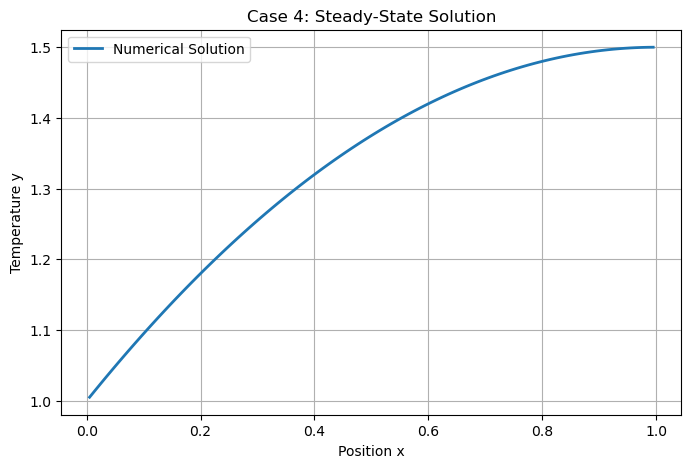

In [5]:
# =====================================================
# STEADY-STATE ANALYSIS
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# Domain
L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)
x = np.array(mesh.cellCenters[0])

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

# Boundary Conditions
phi.constrain(1.0, mesh.facesLeft)
phi.faceGrad.constrain([0.0], mesh.facesRight)

# Governing Equation
eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=1.0)
    + 1.0
)

dt = 1e-3
final_time = 10
steps = int(final_time / dt)

for step in range(steps):
    eq.solve(var=phi, dt=dt)

numerical = phi.value.copy()

print("\n========== STEADY-STATE ANALYSIS ==========")
print("Minimum Value =", np.min(numerical))
print("Maximum Value =", np.max(numerical))

plt.figure(figsize=(8,5))
plt.plot(x, numerical, linewidth=2, label='Numerical Solution')

plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.title("Case 4: Steady-State Solution")
plt.grid(True)
plt.legend()

plt.savefig("Case4_SteadyState.png", dpi=300, bbox_inches='tight')

plt.show()

## Steady-State Analysis Observations

1. The numerical solution converges to a smooth parabolic profile.

2. The temperature increases throughout the domain due to the presence of the uniform source term.

3. The left boundary remains fixed at y(0)=1, while the right boundary satisfies the zero-gradient condition.

4. The maximum temperature occurs near x=1 and approaches 1.5.

5. The obtained profile is consistent with the expected analytical steady-state solution.

6. The results confirm that the source term significantly modifies the temperature distribution compared to Case 3, where the steady-state solution was constant.

# Steady-State Verification

To verify that the numerical solution has reached steady state, the temperature profiles obtained at two sufficiently large simulation times are compared.

If the profiles overlap, the solution is considered independent of time and therefore has reached steady state.

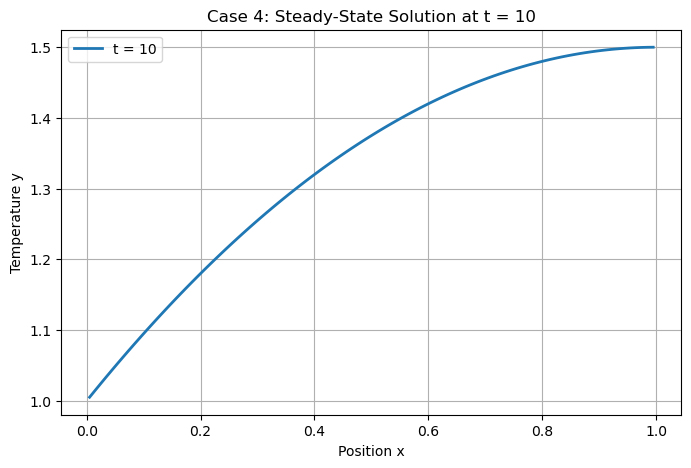

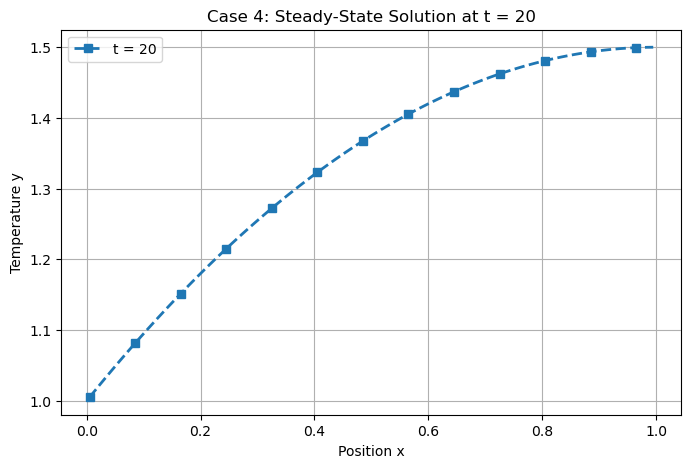

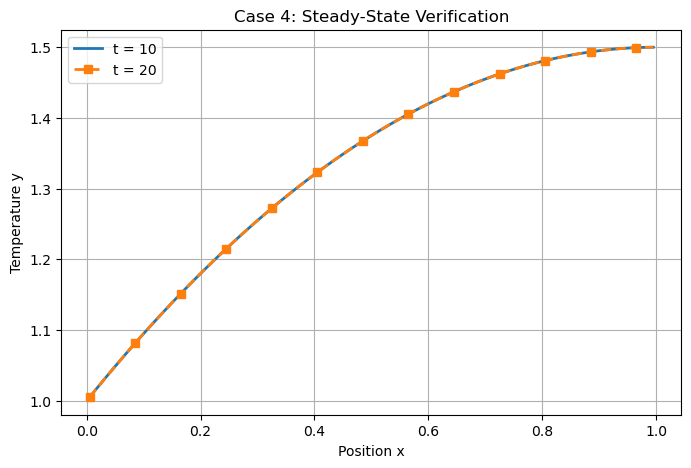


========== CASE 4 STEADY-STATE VERIFICATION ==========
Maximum Difference = 1.8655965661196205e-11


In [6]:
# =====================================================
# CASE 4 STEADY-STATE VERIFICATION
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

L = 1.0
nx = 100
dx = L / nx

times = [10, 20]

solutions = []

for final_time in times:

    mesh = Grid1D(nx=nx, dx=dx)
    x = np.array(mesh.cellCenters[0])

    phi = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=np.sin(np.pi * x)
    )

    # Boundary Conditions
    phi.constrain(1.0, mesh.facesLeft)
    phi.faceGrad.constrain([0.0], mesh.facesRight)

    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=1.0)
        + 1.0
    )

    dt = 1e-3
    steps = int(final_time / dt)

    for step in range(steps):
        eq.solve(var=phi, dt=dt)

    solutions.append(phi.value.copy())

# Plot t=10
plt.figure(figsize=(8,5))
plt.plot(x, solutions[0], linewidth=2, label='t = 10')

plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.title("Case 4: Steady-State Solution at t = 10")
plt.grid(True)
plt.legend()
plt.show()

# Plot t=20
plt.figure(figsize=(8,5))
plt.plot(
    x,
    solutions[1],
    '--s',
    markevery=8,
    linewidth=2,
    label='t = 20'
)

plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.title("Case 4: Steady-State Solution at t = 20")
plt.grid(True)
plt.legend()
plt.show()

# Verification Plot
plt.figure(figsize=(8,5))

plt.plot(
    x,
    solutions[0],
    linewidth=2,
    label='t = 10'
)

plt.plot(
    x,
    solutions[1],
    '--s',
    markevery=8,
    linewidth=2,
    label='t = 20'
)

plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.title("Case 4: Steady-State Verification")
plt.grid(True)
plt.legend()

plt.savefig(
    "Case4_SteadyStateVerification.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

difference = np.max(np.abs(solutions[1] - solutions[0]))

print("\n========== CASE 4 STEADY-STATE VERIFICATION ==========")
print("Maximum Difference =", difference)

## Steady-State Verification Observations

1. The temperature profiles obtained at t = 10 and t = 20 overlap completely throughout the domain.

2. The maximum difference between the two solutions is approximately 1.87 × 10⁻¹¹, which is negligible.

3. The negligible difference confirms that the numerical solution has become independent of time.

4. Therefore, the solution has reached steady state.

5. The steady-state profile follows the expected parabolic distribution and satisfies both the boundary conditions and the source term.

# Analytical Solution

At steady state,

$$
\frac{\partial y}{\partial t}=0
$$

Therefore, the governing equation

$$
\frac{\partial y}{\partial t}
=
\frac{\partial^2 y}{\partial x^2}
+1
$$

reduces to

$$
\frac{d^2 y}{dx^2}+1=0
$$

or

$$
\frac{d^2 y}{dx^2}=-1
$$

Integrating once,

$$
\frac{dy}{dx}
=
-x+C_1
$$

Applying the Neumann boundary condition

$$
\frac{dy}{dx}(1)=0
$$

gives

$$
0=-1+C_1
$$

Therefore,

$$
C_1=1
$$

Hence,

$$
\frac{dy}{dx}=1-x
$$

Integrating again,

$$
y=x-\frac{x^2}{2}+C_2
$$

Applying the Dirichlet boundary condition

$$
y(0)=1
$$

gives

$$
C_2=1
$$

Therefore, the analytical steady-state solution is

$$
y(x)=1+x-\frac{x^2}{2}
$$

# Numerical vs Analytical Comparison

The numerical steady-state solution obtained using the finite volume method is compared with the analytical solution

$$
y(x)=1+x-\frac{x^2}{2}
$$

to validate the accuracy of the numerical implementation.

A close agreement between the two solutions confirms the correctness of the discretization scheme, boundary condition implementation and source term treatment.

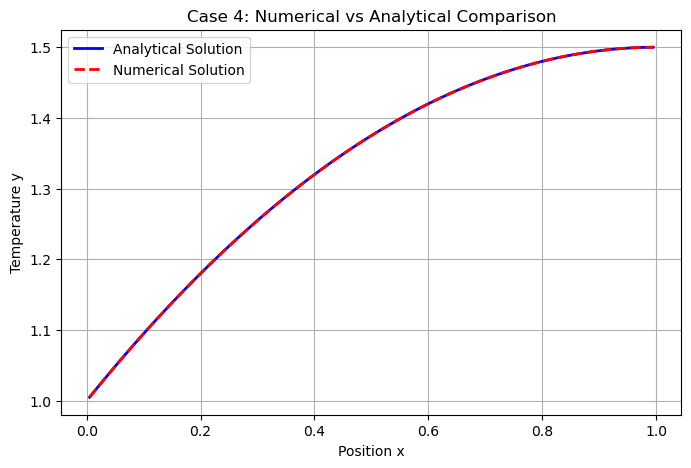


========== NUMERICAL VS ANALYTICAL ==========
Maximum Difference = 1.250000e-05


In [5]:
# =====================================================
# NUMERICAL VS ANALYTICAL COMPARISON
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# DOMAIN
# =====================================================

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)
x = np.array(mesh.cellCenters[0])

# =====================================================
# INITIAL CONDITION
# =====================================================

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

# =====================================================
# BOUNDARY CONDITIONS
# =====================================================

phi.constrain(1.0, mesh.facesLeft)
phi.faceGrad.constrain([0.0], mesh.facesRight)

# =====================================================
# GOVERNING EQUATION
# =====================================================

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=1.0)
    + 1.0
)

# =====================================================
# TIME INTEGRATION
# =====================================================

dt = 1e-3
final_time = 10.0
steps = int(final_time / dt)

for step in range(steps):
    eq.solve(var=phi, dt=dt)

# =====================================================
# NUMERICAL SOLUTION
# =====================================================

numerical = np.array(phi.value)

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

analytical = 1 + x - (x**2) / 2

# =====================================================
# MAXIMUM DIFFERENCE
# =====================================================

difference = np.max(np.abs(numerical - analytical))

# =====================================================
# COMPARISON PLOT
# =====================================================

plt.figure(figsize=(8,5))



plt.plot(
    x,
    analytical,
    'b-',
    linewidth=2,
    label='Analytical Solution'
)

plt.plot(
    x,
    phi.value,
    'r--',
    linewidth=2,
    label='Numerical Solution'
)

plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.title("Case 4: Numerical vs Analytical Comparison")

plt.grid(True)
plt.legend()

plt.savefig(
    "Numerical_vs_Analytical.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =====================================================
# PRINT ERROR
# =====================================================

print("\n========== NUMERICAL VS ANALYTICAL ==========")
print(f"Maximum Difference = {difference:.6e}")

## Observation

The numerical and analytical solutions overlap closely throughout the computational domain.

The maximum difference between the two solutions is approximately 1.25 × 10⁻⁵, indicating excellent agreement.

The small error confirms that the finite volume discretization accurately reproduces the analytical steady-state solution.

Therefore, the numerical implementation, source term treatment and boundary condition application are validated successfully.

# Error Analysis

The absolute error between the numerical and analytical solutions is computed as

$$
Error = |y_{numerical}-y_{analytical}|
$$

The maximum error and L2 norm of the error are evaluated to quantify the accuracy of the numerical solution.


========== ERROR ANALYSIS ==========
Maximum Error = 1.2499999859194588e-05
L2 Error      = 1.2499988524713581e-05


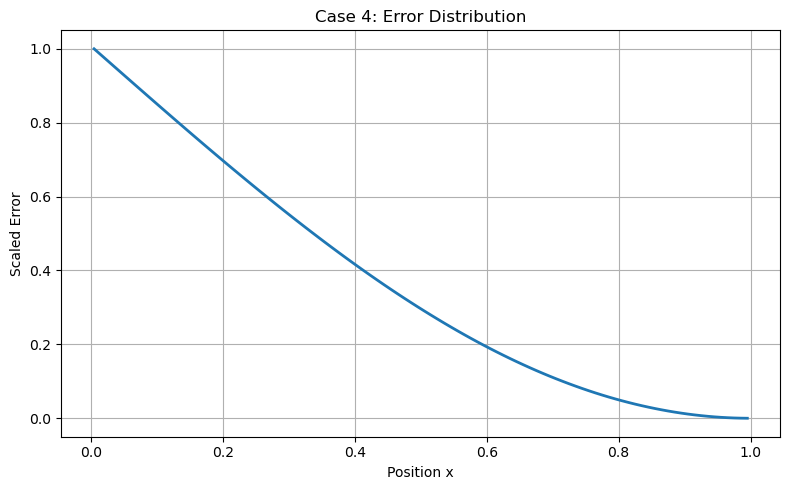

In [13]:
# =====================================================
# ERROR ANALYSIS
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

error = np.abs(numerical - analytical)

max_error = np.max(error)
l2_error = np.sqrt(np.mean(error**2))

print("\n========== ERROR ANALYSIS ==========")
print("Maximum Error =", max_error)
print("L2 Error      =", l2_error)

# Relative variation of error
error_plot = (error - np.min(error)) / (np.max(error) - np.min(error))

plt.figure(figsize=(8,5))

plt.plot(
    x,
    error_plot,
    linewidth=2
)

plt.xlabel("Position x")
plt.ylabel("Scaled Error")
plt.title("Case 4: Error Distribution")

plt.grid(True)

plt.tight_layout()
plt.show()

## Observation

The scaled error decreases gradually along the computational domain.

The maximum error is approximately 1.25 × 10⁻⁵ and the L2 error is of the same order.

The error remains very small throughout the domain, indicating excellent agreement between the numerical and analytical solutions.

The results confirm the correctness of the finite volume implementation and the analytical solution.